In [164]:
import os
import duckdb

os.getcwd()

'C:\\Users\\Hp'

In [165]:
con = duckdb.connect(r"D:\DataQuartz\Kaggle Dataset Practice\Dataset 2\Instacart Market Basket Analysis\Instacart.duckdb")

# STEP 1 — DATASET UNDERSTANDING (Schema Analysis)

## Step 1.1 — Objective

### Objective  
Understand the overall structure of the Instacart dataset, including tables, keys, and relationships before starting analysis.

## Step 1.2 — List of Tables

### Objective  
Identify all tables present in the database.

In [5]:
con.execute("SHOW TABLES").df()

,name
0,aisles
1,departments
2,order_products
3,orders
4,products


### Observation:

Total number of tables: 5

Table names: aisles, department, order_table, orders, products

## Step 1.3 — Orders Data Preview

### Objective  
Inspect sample records from the `orders` table to understand real data patterns.

In [196]:
con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


### Observation  

- Each row in the `orders` table represents a single order placed by a user.  
- The `user_id` column acts as the customer identifier.  
- The table contains order-level information such as:
  - Order sequence (`order_number`)
  - Day of week (`order_dow`)
  - Hour of day (`order_hour_of_day`)
  - Time since last order (`days_since_prior_order`)  

- The table does NOT contain product-level details.  
- This indicates that product information is stored in a separate table and will need to be joined later.

##  Step 1.4 — Order Products Data Preview

### Objective  
Inspect sample records from the `order_products` table to understand how products are linked to orders.

In [9]:
con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


###  Observation  

- Each row in this table represents a single product within an order.  

- I can see that `order_id` repeats multiple times, which means one order can contain multiple products.  

- The `product_id` column shows which product was included in that order, and the same product can appear across different orders.  

- The `add_to_cart_order` column seems to represent the sequence in which items were added to the cart within a single order.  

- The `reordered` column is a flag (0 or 1) indicating whether the product was previously purchased by the same user or not.  

- This table acts as a **bridge (fact table)** between orders and products, enabling analysis of order-level product details.

## Step 1.5 — Products Data Preview

### Objective  
Understand product-level information and how products are categorized.

In [10]:
con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


###  Understanding Table Roles  

- The `orders` table contains order-level information (one row per order).  

- The `order_products` table provides product-level details for each order, where a single order can have multiple rows.  

- The `products` table contains additional information about each product, such as its category and grouping.  

- Overall, `order_products` acts as a bridge between `orders` and `products`.

### Observation  

- Each row in this table represents a single product.  

- The table includes basic product information such as `product_id` and `product_name`.  

- I can also see `aisle_id` and `department_id`, which suggest that each product is categorized into an aisle and a department.  

- These IDs likely connect to separate tables that contain more descriptive information about aisles and departments.  

- Overall, this table provides descriptive details about products rather than transactional data.

###  Understanding Product Table Role  

- This table does not contain any order or transactional data.  

- It only provides product-related information, such as product name and category identifiers.  

- The `product_id` can be used to link this table with order-related tables, but on its own, it cannot be used to analyze sales or order frequency. 

## Step 1.6 — Aisles Table Preview

### Objective  
Understand how products are grouped into aisles.

In [12]:
con.execute("""SELECT * FROM aisles LIMIT 5""").df()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


### Observation  

- Each row in this table represents a single aisle category.  

- The table contains `aisle_id` and `aisle` (aisle name), providing a readable label for each aisle.  

- The `aisle_id` acts as a reference key that is used in the `products` table.  

- This table is purely descriptive and helps in grouping products into broader categories for analysis.

## Step 1.7 — Departments Table Preview

### Objective  
Understand how products are grouped at a higher category level.

In [13]:
con.execute("""SELECT * FROM departments LIMIT 5""").df()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


### Observation  

- Each row in this table represents a department category.  

- The table contains `department_id` and `department` (department name), providing a higher-level grouping of products.  

- The `department_id` serves as a primary key in this table and is referenced in the `products` table.  

- This table is descriptive and helps organize products into broader categories beyond aisles.

## Step 1.8 — Schema Understanding Summary

### Objective  
Summarize the relationships between all tables and understand the overall data model.

### Observation  

- The `orders` table acts as the main table, containing one row per order and representing user purchasing activity.  

- The `order_products` table serves as a bridge between orders and products, providing product-level details for each order.  

- The `products` table contains descriptive information about each product.  

- The `aisles` and `departments` tables further categorize products into broader groups.  

- The tables are connected in the following flow:  
  orders → order_products → products → aisles / departments  

- Overall, analysis typically starts from the `orders` table and expands through joins to include product and category-level details.

## Step 2.1 — Missing Values Check (Orders Table)

### Objective  
Identify missing or NULL values in the `orders` table to ensure data completeness before analysis.

In [123]:
### Data Preview — order table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [27]:
con.execute("""SELECT COUNT(*) AS Total_Count,
                COUNT (order_id) as Orders_Count,
                COUNT(user_id) AS User_Count,
                COUNT(days_since_prior_order) AS Prior_Orders_Count,
                COUNT(*) - COUNT (order_id) as Order_Nulls,
                COUNT(*) - COUNT (user_id) as User_Nulls,
                COUNT(*) - COUNT (days_since_prior_order) as Prior_Day_Nulls
                
                FROM orders
                """).df()

,Total_Count,Orders_Count,User_Count,Prior_Orders_Count,Order_Nulls,User_Nulls,Prior_Day_Nulls
0,3421083,3421083,3421083,3214874,0,0,206209


### Observation  

- The `orders` table does not contain missing values in key columns such as `order_id` and `user_id`, indicating good data completeness.  

- However, the `days_since_prior_order` column contains null values.  

- This is expected, as a user’s first order does not have any prior order to calculate the number of days from.  

- Therefore, these null values are not data quality issues but represent meaningful business logic.

## Step 2.2 — Missing Values Check (Order Products Table)

### Objective  
Identify missing values in the `order_products` table.

In [122]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [30]:
con.execute(""" SELECT COUNT(*) AS Total_Count,
                COUNT(order_id) as Orders_Count,
                COUNT(product_id) as Product_Count,
                COUNT(add_to_cart_order) as Cart_Count,
                COUNT (reordered) as Reordered_Count,
                COUNT(*) - COUNT(order_id) AS Orders_Null,
                COUNT(*) - COUNT(product_id) AS Products_Null,
                COUNT(*) - COUNT(add_to_cart_order) AS Cart_Nulls,
                COUNT(*) - COUNT(reordered) AS Reordered_Nulls

                FROM order_products """).df()

,Total_Count,Orders_Count,Product_Count,Cart_Count,Reordered_Count,Orders_Null,Products_Null,Cart_Nulls,Reordered_Nulls
0,32434489,32434489,32434489,32434489,32434489,0,0,0,0


### Observation  

- The `order_products` table does not contain any missing values across key columns such as `order_id`, `product_id`, `add_to_cart_order`, and `reordered`.  

- Each column is fully populated, which is expected for a transaction-level table where every row represents a product within an order.  

- This indicates strong data quality, as missing values in this table could have affected product-level analysis.

### Understanding Missing Values Across Tables  

- The `orders` table contains null values in the `days_since_prior_order` column because a user’s first order does not have any previous order to reference.  

- These null values are expected and represent meaningful business logic rather than data quality issues.  

- In contrast, the `order_products` table does not contain null values because each row represents a product within an order, and all fields are required to describe that transaction.  

- Since this table captures detailed order-product relationships, missing values would lead to incomplete or incorrect analysis, which is why the data is fully populated.

## Step 2.3 — Duplicate Check (Orders Table)

### Objective  
Verify whether duplicate records exist in the `orders` table.

In [121]:
### Data Preview — order table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [35]:
con.execute(""" SELECT order_id, COUNT(*), 
                FROM orders
                GROUP BY order_id
                HAVING COUNT(*) > 1""").df()

,order_id,count_star()


### Observation  

- A grouping check was performed on `order_id` to identify any duplicate records.  

- No `order_id` values appeared more than once, indicating that each order is uniquely recorded.  

- This confirms that there are no duplicate entries in the `orders` table.

## Step 2.4 — Duplicate Check (Order Products Table)

### Objective  
Verify whether duplicate product entries exist within the same order.

In [120]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [41]:
con.execute(""" SELECT order_id, product_id, COUNT(*)
                FROM order_products
                GROUP BY order_id, product_id
                HAVING COUNT(*) > 1 """).df()

,order_id,product_id,count_star()


### Observation  

- Duplicate check was performed based on the combination of `order_id` and `product_id`, as a duplicate would mean the same product appearing multiple times within a single order.  

- No duplicate combinations were found, indicating that each product is uniquely recorded within an order.  

- This confirms that the `order_products` table maintains proper transactional integrity and does not contain redundant entries.

## Step 2.5 — Order Size Distribution

### Objective  
Understand how many products are typically included in each order.

In [72]:
con.execute(""" SELECT Total_Products, COUNT(order_id) AS Total_Orders,

FROM (

SELECT order_id, COUNT(product_id) as Total_Products
                FROM order_products
                GROUP BY order_id 
                
                )
                
                GROUP BY Total_Products
                
                """).df()

,Total_Products,Total_Orders
0,11,147461
1,16,81192
2,26,20283
3,91,4
4,55,224
...,...,...
108,36,4407
109,68,39
110,69,24
111,98,4


### Observation  

- Most orders contain a small number of products, mainly between 2 to 5 items.  

- This shows that customers usually place small orders instead of buying many items at once.  

- A few orders contain a large number of products, but these are rare.  

- Overall, the data shows that small basket sizes are the most common.

## STEP 2.6 — Orders per User Distribution

### Objective  
Understand how many orders each user places and analyze the distribution of orders per user.

In [119]:
### Data Preview — order table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [69]:
con.execute(""" SELECT COUNT(user_id) AS Total_Users, Total_Orders

FROM (

SELECT user_id, COUNT(Order_id) AS Total_Orders
                FROM orders
                GROUP BY user_id 
                
                )
                
                GROUP BY Total_Orders
                
                """).df()

,Total_Users,Total_Orders
0,554,50
1,162,74
2,904,39
3,1779,28
4,267,63
...,...,...
92,3200,20
93,1015,36
94,189,68
95,185,69


### Observation  

- Users place different numbers of orders, with some users placing only a few orders and others placing many.  

- A large number of users fall in the mid-range of order frequency.  

- Fewer users place a very high number of orders, indicating a smaller group of highly active users.

## Step 3.1 — Top Products Analysis

### Objective  
Identify the most frequently purchased products in the dataset.

In [74]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [118]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [82]:
con.execute(""" SELECT p.product_name, COUNT(op.product_id) as Total_Products
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.product_name
                ORDER BY Total_Products DESC """).df()
                

,product_name,Total_Products
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
...,...,...
49672,Anarchy For Her Daily Fragrance,1
49673,Strawberry Energy Gel,1
49674,Sloppy Joe Sandwich Makers,1
49675,"Freshmatic Ultra Automatic Spray Refill, Vanil...",1


### Observation  

- The most frequently purchased products are primarily fresh produce items such as bananas, strawberries, spinach, and avocados.  

- Organic products appear frequently among the top items, indicating a strong preference for healthier or premium food choices.  

- Bananas appear in multiple forms (regular and organic), suggesting high demand across similar product variations.  

- Overall, customers tend to purchase essential grocery items repeatedly, especially fruits and vegetables.

## Step 3.2 — Reorder Behavior Analysis

### Objective  
Understand how often customers reorder products.

In [117]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [99]:
con.execute(""" SELECT SUM(reordered) * 100 / COUNT(*) as Total_Reordered
                FROM order_products  
                    """).df()

,Total_Reordered
0,58.969747


### Observation
- Around 59% of the products are reordered.
- This indicates that a significant portion of purchases are repeat buys rather than new product exploration.
- Customers tend to stick to familiar products, suggesting consistent buying patterns.

## Step 3.3 — Most Reordered Products

### Objective
Identify the products that are most frequently reordered by customers.

In [115]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [116]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [113]:
con.execute(""" SELECT p.product_name, COUNT(op.product_id) as Total_Order_Count 
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                WHERE reordered = 1
                GROUP BY p.product_name""").df() 

,product_name,Total_Order_Count
0,Vanilla Caramel Fudge Ice Cream,668
1,Extra Long Lasting Polar Ice Flavor Sugarfree Gum,19
2,"Rice Crackers, Original",451
3,Organic Spinach Bunch,6863
4,Ciabatta,1715
...,...,...
45300,Damage Eraser Fortifying Shampoo,1
45301,Kali Bichromicum 30 C,1
45302,Lemon Pear Marmalade,1
45303,Plus Pain Relief Maximum Strength First aid An...,1


### Observation
- Some products show significantly higher reorder counts compared to others, indicating strong repeat demand.
- Items like beverages, fruits, and ready-to-eat products appear frequently among reordered items.
- A large number of products have very low reorder counts (many with just 1), showing long-tail behavior.
- This suggests that while a few products drive repeat purchases, most products are not consistently reordered.

## Step 3.4 — Reorder Rate per Product Analysis

### Objective
Identify which products have the highest reorder rate (i.e., proportion of times they are reordered when purchased).


In [137]:
con.execute(""" SELECT p.product_name, COUNT(op.product_id) AS Total_Products, SUM(op.reordered) AS Total_Reordered,
                ROUND(SUM(op.reordered) / COUNT(op.product_id),2) AS Number_of_Times
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.product_id, p.product_name
                HAVING COUNT(op.product_id) >= 50
                ORDER BY Number_of_Times DESC""").df()

,product_name,Total_Products,Total_Reordered,Number_of_Times
0,Raw Veggie Wrappers,68,64.0,0.94
1,Serenity Ultimate Extrema Overnight Pads,87,81.0,0.93
2,Chocolate Love Bar,101,93.0,0.92
3,Bars Peanut Butter,67,60.0,0.90
4,Sparking Water,60,54.0,0.90
...,...,...,...,...
26681,Organic Lemongrass,52,0.0,0.00
26682,Nonpareil Decorating Decors,51,0.0,0.00
26683,Ground Sage,203,1.0,0.00
26684,Organic Castor Oil Skin Care,67,0.0,0.00


### Observation

- Certain products show very high reorder rates (above 90%), indicating strong customer loyalty and repeat purchasing behavior.

- High reorder rate products are often niche or habitual-use items (e.g., baby products, health items, or daily essentials).

- Products with lower reorder rates (close to 0) suggest one-time or infrequent purchases.

- Applying a minimum order threshold ensures that the analysis focuses on reliable patterns rather than low-volume noise.

- Overall, reorder rate is a strong indicator of product stickiness and customer retention potential.

## Step 3.5 — Basket Size Analysis

### Objective
Understand how many products customers typically purchase in a single order.

In [3]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [4]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [26]:
con.execute(""" SELECT  COUNT(order_id) as Total_Orders, Total_Products
FROM (

SELECT  order_id, COUNT(product_id) as Total_Products
                FROM order_products 
                GROUP BY order_id
                
                
                )

                GROUP BY Total_Products
                ORDER BY Total_Products
                
                """).df()

,Total_Orders,Total_Products
0,156748,1
1,186993,2
2,207027,3
3,222081,4
4,228330,5
...,...,...
108,1,116
109,1,121
110,1,127
111,1,137


### Observation

- Orders containing 4–5 products appear most frequently in the dataset.
- Single-product orders are comparatively lower than multi-product orders.
- The dataset also contains a few extremely large orders, with the maximum observed order containing 116 products.
- This indicates that customers commonly purchase multiple items together rather than placing single-item orders.
- The dataset also contains a few extremely large orders, with the maximum observed order containing 145 products.

## Step 3.6 — Product Diversity Analysis

### Objective

Analyze the relationship between:

- Total orders
- Total products sold
- Total unique products available

In [28]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [30]:
con.execute(""" SELECT COUNT(DISTINCT order_id) AS Total_Orders, COUNT(product_id) as Total_Products,
                COUNT(DISTINCT product_id) as Total_Unique_Products
                FROM order_products """).df()

,Total_Orders,Total_Products,Total_Unique_Products
0,3214874,32434489,49677


## Observation

- The dataset contains over 3.2 million unique orders and more than 32 million product purchases.
- Despite the very high number of product purchases, the platform contains only around 49,677 unique products.
- This indicates that many products are repeatedly purchased across different orders.
- The results suggest strong repeat purchasing behavior rather than customers always purchasing completely new products.
- Overall, the dataset shows a relatively concentrated product catalog compared to total purchasing volume.

## Step 3.7 — Product Popularity by Department

### Objective

Analyze which departments contain the highest number of product purchases across all orders.

In [49]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [48]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [43]:
### Data Preview — departments table

con.execute("""SELECT * FROM departments LIMIT 5""").df()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [54]:
con.execute(""" SELECT d.department, hp.Highest_Purchase

FROM (

                SELECT p.department_id, COUNT(op.product_id) as Highest_Purchase
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.department_id

              ) hp

              LEFT JOIN departments d
              ON hp.department_id = d.department_id
              ORDER BY hp.Highest_Purchase DESC
               
                
                """).df()

,department,Highest_Purchase
0,produce,9479291
1,dairy eggs,5414016
2,snacks,2887550
3,beverages,2690129
4,frozen,2236432
5,pantry,1875577
6,bakery,1176787
7,canned goods,1068058
8,deli,1051249
9,dry goods pasta,866627


## Observation

- The Produce department has the highest number of product purchases in the dataset.
- Dairy Eggs and Snacks are also among the most frequently purchased departments.
- Most top-performing departments consist of daily-use or frequently consumed grocery items.
- Beverage and Frozen product categories also contribute significantly to overall purchase volume.
- The results indicate that customers primarily purchase essential and recurring household food items.

## Step 3.8 — Product Popularity by Aisle

### Objective

Analyze which aisles contain the highest number of product purchases across all orders.

In [63]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [64]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [57]:
### Data Preview — aisles table

con.execute("""SELECT * FROM aisles LIMIT 5""").df()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [59]:
con.execute(""" SELECT a.aisle, hp.Highest_Purchase

FROM (

SELECT p.aisle_id, COUNT(op.product_id) as Highest_Purchase
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.aisle_id
                ORDER BY Highest_Purchase DESC
                
                ) hp

                LEFT JOIN aisles a
                ON a.aisle_id = hp.aisle_id
                
                """).df()

,aisle,Highest_Purchase
0,fresh fruits,3642188
1,fresh vegetables,3418021
2,packaged vegetables fruits,1765313
3,yogurt,1452343
4,packaged cheese,979763
...,...,...
129,eye ear care,8974
130,baby bath body care,8581
131,baby accessories,8160
132,beauty,6168


### Observation

- Fresh Fruits is the most purchased aisle in the dataset.
- Fresh Vegetables and Packaged Vegetables Fruits also show very high purchase volumes.
- Dairy-related aisles such as Yogurt and Packaged Cheese are among the top-performing aisles.
- Most highly purchased aisles consist of fresh and frequently consumed grocery items.
- The results indicate strong customer demand for essential food categories and recurring household purchases.

## Step 3.9 — Average Cart Position Analysis

### Objective

Analyze at what cart position products are typically added during customer purchases.

In [66]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [65]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [73]:
con.execute(""" SELECT p.product_name, AVG(op.add_to_cart_order) AS Cart_Position
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.product_name
                HAVING COUNT(op.product_id) >= 50
                ORDER BY Cart_Position""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_name,Cart_Position
0,"Flavored Vodka, Peach",2.197183
1,Rehab Energy Iced Tea Orangeade,2.292308
2,Pure Mint With Herbal Accent Sugar Free Gum,2.348315
3,Alimentum Infant Formula,2.405405
4,Vodka 80 Proof,2.439560
...,...,...
26681,Strong Honey Mustard Bar,16.318841
26682,Multi-Grain Blend W/Spinach Tomato & Onions Pa...,16.418919
26683,Organic Black Bean Beet Banana Baby Food,16.710526
26684,Spicy Fiesta Sprouted Flax Snax,18.402597


### Observation

- Products such as flavored beverages, gum, and infant formula are typically added very early in customer carts.
- Several products show low average cart positions, indicating they are priority or intentionally searched items during shopping sessions.
- Products with higher average cart positions are generally added later in the shopping process.
- Applying a minimum purchase threshold improves reliability by removing low-frequency products with unstable averages.
- Overall, cart position analysis helps identify which products customers prioritize first while building their orders.

## Step 3.10 — Department Reorder Analysis

### Objective

Analyze which departments have the highest reorder behavior across customer purchases.

In [74]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [75]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [76]:
### Data Preview — departments table

con.execute("""SELECT * FROM departments LIMIT 5""").df()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [82]:
con.execute(""" SELECT d.department, tr.Total_Reordered

FROM (

SELECT p.department_id, SUM(op.reordered) AS Total_Reordered, COUNT(op.product_id) AS Total_Products
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.department_id
                
                ) tr

                LEFT JOIN departments d
                ON tr.department_id = d.department_id

                ORDER BY tr.Total_Reordered DESC
                
                """).df()

,department,Total_Reordered
0,produce,6160710.0
1,dairy eggs,3627221.0
2,beverages,1757892.0
3,snacks,1657973.0
4,frozen,1211890.0
5,bakery,739188.0
6,pantry,650301.0
7,deli,638864.0
8,canned goods,488535.0
9,meat seafood,402442.0


### Observation

- Produce has the highest reorder volume among all departments.
- Frozen and Bakery departments also show strong reorder behavior.
- Essential grocery-related departments dominate customer repeat purchases.
- Departments such as Alcohol and Other show comparatively lower reorder activity.
- The results indicate that customers frequently reorder routine household and food-related products.

## Step 3.11 — Aisle Reorder Analysis

### Objective

Analyze which aisles have the highest reorder behavior across customer purchases.

In [83]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [84]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [85]:
### Data Preview — aisles table

con.execute("""SELECT * FROM aisles LIMIT 5""").df()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [87]:
con.execute(""" SELECT a.aisle, tr.Total_Reordered

FROM (

SELECT p.aisle_id, SUM(op.reordered) as Total_Reordered, COUNT(op.product_id) AS Total_Products
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.aisle_id 

                ) tr

                LEFT JOIN aisles a
                ON a.aisle_id = tr.aisle_id
                ORDER BY tr.Total_Reordered DESC
                

                """).df()

,aisle,Total_Reordered
0,fresh fruits,2615469.0
1,fresh vegetables,2032172.0
2,packaged vegetables fruits,1127177.0
3,yogurt,997018.0
4,milk,696264.0
...,...,...
129,frozen juice,2188.0
130,first aid,2118.0
131,eye ear care,1950.0
132,kitchen supplies,1792.0


### Observation

- Fresh Fruits has the highest reorder volume among all aisles.
- Fresh Vegetables and Packaged Vegetables Fruits also show very strong repeat purchasing behavior.
- Dairy-related aisles such as Yogurt and Milk are frequently reordered by customers.
- Most top reordered aisles consist of fresh and essential grocery products.
- The results indicate that customers repeatedly purchase everyday food and household consumption items.

## Step 3.12 — First vs Repeat Purchase Analysis

### Objective

Analyze the proportion of first-time purchases versus reordered purchases across all product orders.

In [88]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [92]:
con.execute(""" SELECT CASE 
                        WHEN reordered = 0 THEN 'First Time Purchase'
                        ELSE 'Reordered Purchase' END AS Total_Purchases,
                        COUNT(product_id) AS Total_Products
                        FROM order_products
                        GROUP BY Total_Purchases""").df()
                        

,Total_Purchases,Total_Products
0,First Time Purchase,13307953
1,Reordered Purchase,19126536


### Observation

- Reordered purchases are significantly higher than first-time purchases in the dataset.
- More than 19 million purchases are reordered, compared to around 13 million first-time purchases.
- This indicates strong customer retention and repeat purchasing behavior.
- Customers frequently repurchase products they have previously bought rather than constantly exploring new items.
- The results suggest that recurring grocery and household purchases dominate customer shopping patterns.

## Step 3.13 — Product Purchase Distribution Analysis

### Objective

Analyze how product purchases are distributed across products to identify whether a small number of products dominate total sales volume.

In [93]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [94]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [98]:
con.execute(""" SELECT p.product_name, COUNT(op.order_id) as Total_Orders
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                GROUP BY p.product_name
                ORDER BY Total_Orders DESC """).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_name,Total_Orders
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
...,...,...
49672,Cinnamon Rice Pudding Snacks,1
49673,Dried Porcini Mushroom,1
49674,Dynostix Rawhide Chew With Meat,1
49675,Rosa Mosqueta Rose Hip Seed Oil,1


### Observation

- A small number of products dominate overall purchase volume in the dataset.
- Products such as Banana, Bag of Organic Bananas, and Organic Strawberries have extremely high purchase counts compared to most other products.
- Many products appear only once or a very small number of times, indicating a long-tail distribution.
- Fresh produce and organic grocery items are among the most frequently purchased products.
- The results suggest that customer demand is highly concentrated around a relatively small set of popular products.

## Step 3.14 — Organic vs Non-Organic Product Analysis

### Objective

Analyze purchasing patterns between organic and non-organic products.

In [104]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [100]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [111]:
con.execute(""" SELECT COUNT(op.product_id) as Total_Products,
                CASE 
                    WHEN p.product_name LIKE 'Organic%' THEN 'Organic'
                    ELSE 'Non Organic' END AS Category

                    
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id 
                GROUP BY Category
                ORDER BY Category
                 """).df()

,Total_Products,Category
0,23412652,Non Organic
1,9021837,Organic


### Observation

- Non-Organic products account for the majority of product purchases in the dataset.
- Organic products still represent a significant portion of overall purchases, with more than 9 million product orders.
- The results indicate strong customer demand for organic grocery items despite non-organic products dominating total sales volume.
- Organic purchasing behavior appears especially relevant within grocery and fresh produce categories.
- Overall, customers purchase both organic and non-organic products extensively, but non-organic products remain more common.

## Step 3.15 — Product Reorder Timing Analysis

### Objective

Analyze how many days customers typically wait before reordering products.

In [168]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [113]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [126]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [138]:
con.execute(""" SELECT p.product_name, pd.Prior_Days

FROM (

SELECT op.product_id, AVG(o.days_since_prior_order) AS Prior_Days
                    
                        FROM order_products op
                        LEFT JOIN orders o
                        ON op.order_id = o.order_id
                        WHERE reordered = 1
                        GROUP BY op.product_id
                        HAVING COUNT(op.product_id) >= 20
                        
                        ) pd

                        LEFT JOIN products p
                        ON p.product_id = pd.product_id
                        ORDER BY Prior_Days
                        LIMIT 20
                        
                        
                        """).df()

,product_name,Prior_Days
0,French Bread Baguette,1.428571
1,"Toothpaste, Calendula",1.585366
2,Almond Orgeat Syrup,2.458333
3,Mango Syrup,2.485714
4,Hummus Wrap,2.967742
5,Barley Toddler Biscuits,3.133333
6,Chocolate Love Bar,3.161290
7,Dark 83% Pure Dark Chocolate Bite,3.191781
8,Extra Virgin Olive Oil Blend,3.341463
9,Vodka Vanilia,3.384615


### Observation

- The `days_since_prior_order` column helps measure how long customers wait before placing another order.
- First orders contain `NULL/NaN` values because there is no previous order to compare against.
- Customers show varying reorder intervals, with some reordering within a few days while others wait several weeks.
- The dataset suggests that reorder behavior is not fixed and differs across users and products.

## Step 3.16 — Fastest Reordered Products Analysis

### Objective

Identify which products are reordered again in the shortest amount of time on average.

In [141]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [142]:
### Data Preview — products table

con.execute("""SELECT * FROM products LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [143]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [167]:
con.execute(""" SELECT op.product_id, p.product_name, AVG(o.days_since_prior_order) as Avg_Prior_Order,
                
                FROM order_products op
                LEFT JOIN products p
                ON op.product_id = p.product_id
                LEFT JOIN orders o
                ON op.order_id = o.order_id
                WHERE reordered = 1
                GROUP BY op.product_id, p.product_name
                HAVING COUNT(op.product_id) >= 20
                ORDER BY Avg_Prior_Order

                """).df()

,product_id,product_name,Avg_Prior_Order
0,44360,French Bread Baguette,1.428571
1,24944,"Toothpaste, Calendula",1.585366
2,38438,Almond Orgeat Syrup,2.458333
3,21402,Mango Syrup,2.485714
4,453,Hummus Wrap,2.967742
...,...,...,...
25615,17960,At-Home Dry Cleaner Refill 8 Load,20.571429
25616,42505,Creamy Vodka Italian Sauce,20.619048
25617,41336,Noticeables Febreze NOTICEables Gain Original ...,20.650000
25618,8926,Liquid Laundry Detergent,20.973684


### Observation

- Some products are reordered extremely quickly, often within 1–3 days on average.
- Fast reordered products such as bread, wraps, and consumable grocery items likely represent high daily usage behavior.
- Products with larger average reorder gaps are typically slower-consumption or less frequently needed items.
- Applying the minimum reorder threshold (`HAVING COUNT(op.product_id) >= 20`) improves result reliability by excluding products with very few reorder records.

## Step 3.17 — Weekend vs Weekday Ordering Behavior

### Objective

Analyze whether customers place more orders on weekdays or weekends to understand shopping behavior patterns.

In [169]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [171]:
con.execute(""" SELECT CASE
                        WHEN order_dow BETWEEN 1 AND 5 THEN 'Weekday'
                        ELSE 'Weekend' END AS Day_Of_Week, COUNT(order_id) as Total_Orders
                FROM orders
                GROUP BY Day_Of_Week
                ORDER BY Total_Orders""").df()

,Day_Of_Week,Total_Orders
0,Weekend,1049666
1,Weekday,2371417


### Observation

- Customers place significantly more orders on weekdays compared to weekends.
- Weekday orders are more than double the weekend order volume, indicating that shopping activity is more frequent during regular working days.
- This pattern may suggest that users commonly place routine grocery orders throughout the week rather than saving purchases for weekends.

## Step 3.18 — Reorder Rate by Time of Day

### Objective

Analyze how reorder behavior changes throughout different times of the day to identify when customers are more likely to reorder products.

In [172]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [173]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [183]:
con.execute(""" SELECT order_hour_of_day, AVG(reordered) as Avg_Reordered
                FROM orders o
                LEFT JOIN order_products op
                ON o.order_id = op.order_id
                GROUP BY order_hour_of_day
                ORDER BY order_hour_of_day
                
                """).df()

,order_hour_of_day,Avg_Reordered
0,00,0.565500
1,01,0.557114
2,02,0.554455
3,03,0.559498
4,04,0.571195
5,05,0.607947
6,06,0.636497
7,07,0.644473
8,08,0.631883
9,09,0.619449


### Observation

- Reorder rates vary throughout the day, showing that customer purchasing behavior changes by hour.
- Early morning hours show relatively higher reorder rates, indicating that repeat purchases are more common during these periods.
- Since `AVG(reordered)` measures the proportion of reordered products, values closer to 1 indicate stronger repeat-purchase behavior.
- Grouping by `order_hour_of_day` helps identify peak reorder activity times and customer shopping patterns across the day.

# Step 4 — Customer Segmentation Analysis

## Step 4.1 — Customer Loyalty Segmentation

### Objective

Segment customers into Casual, Regular, and Loyal groups based on their total number of orders.

In [24]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [51]:
con.execute(""" SELECT COUNT(order_id) as Total_Orders, user_id, CASE
                                            WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                            WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                            ELSE 'Loyal Customers' END as Loyalty_Group
                FROM orders
                GROUP BY user_id
                ORDER BY Loyalty_Group
                 """).df()

,Total_Orders,user_id,Loyalty_Group
0,6,14879,Casual Customers
1,4,14899,Casual Customers
2,4,14917,Casual Customers
3,10,14928,Casual Customers
4,6,14932,Casual Customers
...,...,...,...
206204,13,117937,Regular Customers
206205,19,76297,Regular Customers
206206,20,193903,Regular Customers
206207,11,12439,Regular Customers


### Observation

- Customers were successfully segmented into Casual, Regular, and Loyal groups based on their total number of orders.
- Most users appear in the Casual Customer category, indicating that lower-order-frequency users make up a large portion of the customer base.
- Loyalty segmentation helps identify highly engaged repeat customers who may contribute more consistently to overall sales activity.
- This type of customer grouping can support targeted marketing, retention strategies, and personalized promotions.

## Step 4.2 — Loyalty Group Distribution Analysis

### Objective

Analyze the distribution of customers across each loyalty segment to understand which customer group represents the largest portion of the user base.

In [22]:
con.execute(""" SELECT COUNT(user_id) as Total_Users, Loyalty_Group

FROM (

SELECT COUNT(order_id) as Total_Orders, user_id, CASE
                                            WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                            WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                            ELSE 'Loyal Customers' END as Loyalty_Group
                FROM orders
                GROUP BY user_id
                ORDER BY Loyalty_Group

                )

                GROUP BY Loyalty_Group 
                ORDER BY Total_Users DESC

                
                 """).df()

,Total_Users,Loyalty_Group
0,104513,Casual Customers
1,50965,Regular Customers
2,50731,Loyal Customers


### Observation

- Casual Customers represent the largest customer segment in the dataset.
- Regular and Loyal Customers have relatively similar customer counts.
- The results suggest that most users place a smaller number of orders, while a smaller portion of customers become highly active repeat buyers.
- Customer segmentation helps identify purchasing behavior patterns and can support targeted marketing or retention strategies.

## Step 4.3 — Average Orders per Customer Segment

### Objective

Analyze the average number of orders placed by users inside each loyalty group.

In [25]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [50]:
con.execute(""" SELECT  AVG(Total_Orders) AS Avg_Orders, Loyalty_Group

FROM (

            SELECT user_id, COUNT(order_id) AS Total_Orders, 
                CASE 
                    WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                    WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                    ELSE 'Loyal Customers' END AS Loyalty_Group

            FROM orders
            GROUP BY user_id
             
                
                )

                GROUP BY Loyalty_Group
                ORDER BY Avg_Orders
                
                """).df()

,Avg_Orders,Loyalty_Group
0,6.348148,Casual Customers
1,14.680918,Regular Customers
2,39.609036,Loyal Customers


### Observation

- Casual Customers place the fewest orders on average.
- Regular Customers show moderate purchasing activity.
- Loyal Customers have significantly higher average order counts compared to other customer groups.
- The results confirm that the customer segmentation logic successfully separates users based on purchasing frequency.

## Step 4.4 — Reorder Rate by Customer Segment

### Objective

Analyze how reorder behavior changes across different customer loyalty groups.

In [33]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [54]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products  LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [48]:
con.execute(""" SELECT AVG(op.reordered) AS Average_Reordered, o.Loyalty_Group

    FROM (
            SELECT o.order_id, lg.Loyalty_Group
            
                    FROM (

                        SELECT user_id, COUNT(order_id) AS Total_Orders, 
                            CASE 
                                WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                ELSE 'Loyal Customers' END AS Loyalty_Group

                        FROM orders
                        GROUP BY user_id
             
                        ) lg

            LEFT JOIN orders o
            ON o.user_id = lg.user_id
            GROUP BY o.order_id, lg.Loyalty_Group

                ) o

        LEFT JOIN order_products op
        ON o.order_id = op.order_id

        GROUP BY o.Loyalty_Group
        

                """).df()

,Average_Reordered,Loyalty_Group
0,0.507756,Regular Customers
1,0.688497,Loyal Customers
2,0.334741,Casual Customers


### Observation

- Loyal Customers have the highest reorder rate among all customer segments.
- Casual Customers show the lowest reorder behavior.
- Regular Customers fall between Casual and Loyal segments in reorder activity.
- The results suggest that highly engaged customers are more likely to repeatedly purchase the same products.

## Step 4.5 — Average Basket Size by Customer Segment

### Objective

Analyze how basket size differs across Casual, Regular, and Loyal customers.

In [57]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products  LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [74]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [76]:
con.execute(""" SELECT op.order_id, COUNT(op.product_id) AS Basket_Size, o.Loyalty_Group

    FROM (
            SELECT o.order_id, lg.Loyalty_Group
            
                    FROM (

                        SELECT user_id, COUNT(order_id) AS Total_Orders, 
                            CASE 
                                WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                ELSE 'Loyal Customers' END AS Loyalty_Group

                        FROM orders
                        GROUP BY user_id
             
                        ) lg

            LEFT JOIN orders o
            ON o.user_id = lg.user_id
            GROUP BY o.order_id, lg.Loyalty_Group

                ) o

        LEFT JOIN order_products op
        ON o.order_id = op.order_id

        GROUP BY op.order_id, o.Loyalty_Group
        
                 """).df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,order_id,Basket_Size,Loyalty_Group
0,25949,3,Loyal Customers
1,25954,13,Regular Customers
2,26016,7,Casual Customers
3,26116,6,Loyal Customers
4,26170,8,Loyal Customers
...,...,...,...
3214872,3420891,10,Loyal Customers
3214873,3420963,3,Regular Customers
3214874,3420966,14,Loyal Customers
3214875,3420975,4,Loyal Customers


### Observation

- Basket size now correctly represents the number of products inside each order.
- Loyal and Regular Customers tend to place larger orders compared to Casual Customers.
- The analysis shows that highly engaged customers generally purchase more items per transaction.

# Step 5 — Product Category Analysis

## Step 5.1 — Most Popular Departments

### Objective

Analyze which departments receive the highest number of product purchases.

In [77]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products  LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [80]:
### Data Preview — products table

con.execute("""SELECT * FROM products  LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [82]:
### Data Preview — departments table

con.execute("""SELECT * FROM departments LIMIT 5""").df()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [93]:
con.execute(""" SELECT COUNT(op.product_id) AS Total_Products, dep.department


        FROM (

            SELECT p.product_id, d.department
            FROM departments d
            LEFT JOIN products p
            ON d.department_id = p.department_id
            GROUP BY p.product_id, d.department
                
                ) dep

        LEFT JOIN order_products op
        ON op.product_id = dep.product_id

        GROUP BY dep.department
        ORDER BY Total_Products DESC


                
                """).df()

,Total_Products,department
0,9479291,produce
1,5414016,dairy eggs
2,2887550,snacks
3,2690129,beverages
4,2236432,frozen
5,1875577,pantry
6,1176787,bakery
7,1068058,canned goods
8,1051249,deli
9,866627,dry goods pasta


### Observation

- Produce is the most purchased department, showing extremely high customer demand for fresh items.
- Dairy & Eggs and Snacks are also among the most frequently purchased categories.
- Essential grocery departments dominate purchasing behavior across the platform.

## Step 5.2 — Most Popular Aisles

### Objective

Analyze which aisles receive the highest number of product purchases.

In [91]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products  LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [92]:
### Data Preview — products table

con.execute("""SELECT * FROM products  LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [90]:
### Data Preview — aisles table

con.execute("""SELECT * FROM aisles  LIMIT 5""").df()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [96]:
con.execute(""" SELECT COUNT(op.product_id) as Total_Products, ai.aisle

            FROM ( 

                SELECT p.product_id, p.aisle_id, a.aisle
                FROM aisles a
                LEFT JOIN products p
                ON a.aisle_id = p.aisle_id

                GROUP BY p.aisle_id, a.aisle, p.product_id

                ) ai

                LEFT JOIN order_products op
                ON ai.product_id = op.product_id

                GROUP BY ai.aisle
                
                
                """).df()

,Total_Products,aisle
0,34303,dog food care
1,144189,grains rice dried goods
2,234065,cookies cakes
3,979763,packaged cheese
4,71860,breakfast bars pastries
...,...,...
129,62510,marinades meat preparation
130,22664,mint gum
131,11198,specialty wines champagnes
132,6168,beauty


### Observation

- Certain aisles receive significantly higher purchase activity than others.
- Packaged cheese, grains/rice goods, and snack-related aisles show strong customer demand.
- Frequently purchased aisles mostly belong to everyday grocery and convenience food categories.

## Step 5.3 — Department Reorder Analysis

### Objective

Analyze which departments have the highest product reorder behavior.

In [103]:
### Data Preview — products table

con.execute("""SELECT * FROM products  LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [100]:
### Data Preview — departments table

con.execute("""SELECT * FROM departments  LIMIT 5""").df()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [102]:
### Data Preview — order_products table

con.execute("""SELECT * FROM order_products LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [115]:
con.execute(""" SELECT dp.department, COUNT(op.product_id) as Total_Products
    
    FROM (
                SELECT p.department_id, p.product_id, d.department
                FROM departments d
                LEFT JOIN products p
                ON p.department_id = d.department_id
                GROUP BY p.department_id, d.department, p.product_id 

                ) dp

                LEFT JOIN order_products op
                ON dp.product_id = op.product_id 
                WHERE op.reordered = 1
                GROUP BY dp.department
                ORDER BY Total_Products DESC
                
                """).df()

        


,department,Total_Products
0,produce,6160710
1,dairy eggs,3627221
2,beverages,1757892
3,snacks,1657973
4,frozen,1211890
5,bakery,739188
6,pantry,650301
7,deli,638864
8,canned goods,488535
9,meat seafood,402442


### Observation

- Produce has the highest reorder activity, indicating customers frequently repurchase fresh grocery items.
- Dairy & Eggs and Beverages also show strong reorder behavior.
- Essential daily-use departments tend to generate the most repeat purchasing activity.

## Step 5.4 — Department Diversity Analysis

### Objective

Analyze how many unique products exist within each department to understand category variety.

In [116]:
### Data Preview — products table

con.execute("""SELECT * FROM products  LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [117]:
### Data Preview — departments table

con.execute("""SELECT * FROM departments  LIMIT 5""").df()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [125]:
con.execute(""" SELECT  d.department, COUNT(DISTINCT p.Product_id) AS Unique_Products
                FROM departments d
                LEFT JOIN Products p
                ON p.department_id = d.department_id
                GROUP BY  d.department""").df()

,department,Unique_Products
0,dry goods pasta,1858
1,missing,1258
2,bakery,1516
3,meat seafood,907
4,bulk,38
5,pantry,5371
6,frozen,4007
7,pets,972
8,babies,1081
9,snacks,6264


### Observation

The analysis shows the number of unique products available in each department. Departments such as Personal Care, Snacks, and Beverages contain a large variety of products, indicating broader product diversity. Smaller departments like Alcohol and Breakfast contain comparatively fewer unique products.

## Step 5.5 — Aisle Diversity Analysis

### Objective

Analyze which aisles contain the highest variety of unique products.

In [123]:
### Data Preview — products table

con.execute("""SELECT * FROM products  LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [124]:
### Data Preview — aisle table

con.execute("""SELECT * FROM aisles  LIMIT 5""").df()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [126]:
con.execute(""" SELECT a.aisle, COUNT(DISTINCT p.product_id) as Unique_Products
                FROM aisles a
                LEFT JOIN products p
                ON a.aisle_id = p.aisle_id
                GROUP BY a.aisle
                ORDER BY Unique_Products """).df()

,aisle,Unique_Products
0,bulk dried fruits vegetables,12
1,bulk grains rice dried goods,26
2,packaged produce,32
3,baby accessories,44
4,frozen juice,47
...,...,...
129,yogurt,1026
130,vitamins supplements,1038
131,ice cream ice,1091
132,candy chocolate,1246


### Observation

The analysis highlights product diversity across aisles by measuring the number of unique products available in each aisle. Certain aisles such as Yogurt and Vitamins & Supplements contain a large variety of products, while smaller aisles like Bulk Dried Fruits Vegetables contain limited product diversity.

## Step 5.6 — Average Add-to-Cart Position by Department

### Objective

Analyze at what stage of shopping products from each department are typically added to the cart.

In [129]:
### Data Preview — products table

con.execute("""SELECT * FROM order_products  LIMIT 5""").df()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [127]:
### Data Preview — products table

con.execute("""SELECT * FROM products  LIMIT 5""").df()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [138]:
### Data Preview — products table

con.execute("""SELECT * FROM departments  LIMIT 5""").df()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [136]:
con.execute("""SELECT dp.department, AVG(op.add_to_cart_order) AS Avg_ATC

FROM (

SELECT d.department, p.product_id
                FROM departments d
                LEFT JOIN products p
                ON d.department_id = p.department_id
                GROUP BY d.department, p.product_id
                
                ) dp

                LEFT JOIN order_products op
                ON dp.product_id = op.product_id
                GROUP BY dp.department
                ORDER BY Avg_ATC
                
                """).df()

,department,Avg_ATC
0,alcohol,5.428346
1,beverages,6.976699
2,dairy eggs,7.495423
3,pets,7.718544
4,produce,8.022875
5,bakery,8.084397
6,other,8.277645
7,bulk,8.399040
8,household,8.492163
9,meat seafood,8.528225


### Observation

The analysis shows the average cart position at which products from each department are added during shopping. Departments such as Alcohol and Beverages are typically added earlier in the cart, while departments with higher average add-to-cart positions are generally selected later in the shopping process.

# Step 6 — Customer Behavior Analysis

## Step 6.1 — Average Days Between Orders

### Objective

Analyze how frequently customers place orders by measuring the average number of days between purchases.

In [148]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [149]:
con.execute(""" SELECT  COUNT(order_id) as Total_Orders, AVG(days_since_prior_order) AS Avg_Days
                FROM orders
                """).df()

,Total_Orders,Avg_Days
0,3421083,11.114836


## Observation

The analysis shows that customers place a new order approximately every 11 days on average. This indicates relatively frequent purchasing behavior and suggests strong repeat engagement on the platform.

## Step 6.2 — Orders by Day of Week

### Objective

Analyze which days of the week receive the highest number of orders to identify customer purchasing patterns across the week.

In [153]:
con.execute(""" SELECT order_dow, COUNT(order_id) AS Total_Orders
                FROM orders
                GROUP BY order_dow """).df()

,order_dow,Total_Orders
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


## Observation

The analysis shows that customer ordering activity varies across different days of the week. Days represented by values 0 and 1 recorded the highest number of orders, while later weekdays showed comparatively lower purchasing activity.

## Step 6.3 — Orders by Hour of Day

### Objective

Analyze how customer orders are distributed across different hours of the day to identify peak shopping hours and customer purchasing patterns.

In [155]:
con.execute(""" SELECT order_hour_of_day, COUNT(order_id) AS Total_Orders
                FROM orders
                GROUP BY order_hour_of_day
                ORDER BY order_hour_of_day""").df()

,order_hour_of_day,Total_Orders
0,00,22758
1,01,12398
2,02,7539
3,03,5474
4,04,5527
5,05,9569
6,06,30529
7,07,91868
8,08,178201
9,09,257812


## Observation

The analysis shows that customer ordering activity is lowest during late night and early morning hours, especially between 2 AM and 5 AM. Order volume starts increasing after 6 AM and reaches peak activity during late morning and afternoon hours, indicating that customers mostly shop during daytime.

## Step 6.4 — Weekly Ordering Trends

### Objective

Analyze ordering trends across the week by comparing daily order activity patterns to identify the busiest and slowest shopping days.

In [156]:
### Data Preview — orders table

con.execute("""SELECT * FROM orders LIMIT 5""").df()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,07,29.0
4,431534,1,prior,5,4,15,28.0


In [161]:
con.execute("""  SELECT order_dow, COUNT(order_id) AS Total_Orders
                FROM orders
                GROUP BY order_dow 
                
                """).df()

,order_dow,Total_Orders
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


## Step 7.1 — Key Business Insights Summary

### Objective

Summarize the most important business findings discovered throughout the analysis project, including customer behavior, product trends, reorder patterns, shopping habits, and operational insights. This section transforms raw analysis into meaningful business intelligence that can support decision-making and strategic planning.

---

## Observation

- Produce, dairy eggs, and snacks emerged as the most purchased departments, indicating consistently high customer demand for everyday grocery essentials.

- Loyal customers generally placed larger orders and purchased more products per transaction compared to casual customers, highlighting stronger engagement and repeat purchasing behavior.

- Several products showed extremely high reorder frequency, suggesting strong customer retention and habitual buying patterns for essential grocery items.

- Basket size analysis revealed that customers commonly purchase multiple products within a single order, reflecting bulk or routine grocery shopping behavior.

- Department and aisle diversity analysis showed that some categories contain a significantly wider product variety, especially pantry, snacks, beverages, and personal care.

- Time-based analysis indicated that customer activity peaks during daytime and evening hours, while late-night ordering activity remains relatively low.

- Weekly order distribution showed stronger purchasing activity at the beginning of the week compared to midweek periods.

- Average add-to-cart position analysis suggested that frequently purchased essential items are typically added earlier in shopping sessions, indicating planned purchasing behavior.

- Reorder behavior demonstrated that staple grocery categories contribute heavily to repeat purchases and long-term customer retention.

- Overall analysis reveals that customer purchasing behavior is strongly influenced by convenience, repeat buying habits, and high-demand essential product categories.

## Step 7.2 — Business Recommendations

### Objective

Provide practical business recommendations based on the analytical insights discovered throughout the project. This section focuses on how the company can improve customer engagement, product strategy, inventory planning, and operational decision-making using data-driven insights.

## Observation

- The analysis suggests that customers frequently reorder everyday grocery items such as produce, dairy, and snacks, making these categories especially important for inventory planning and product availability.

- Loyal customers tend to place larger and more frequent orders, which means targeted loyalty programs and personalized offers could help strengthen long-term customer retention.

- Since customers are most active during daytime and evening hours, marketing campaigns, delivery scheduling, and promotional notifications can be better timed around these peak shopping periods.

- Products that customers consistently add early in their shopping sessions are likely essential items, so highlighting these products strategically could improve overall shopping experience and sales performance.

- Departments with strong reorder activity provide stable recurring demand, while lower-performing categories may benefit from improved promotions, recommendations, or product assortment strategies.

- Overall, customer purchasing behavior appears heavily driven by convenience, repeat buying habits, and routine grocery shopping patterns, which can help support more effective business and operational decisions.

## Step 7.3 — Visualizations & Dashboard

### Objective

Create visualizations and dashboard-style summaries to present key analytical findings in a clearer and more business-friendly format.

In [167]:
## Orders by Hour of Day

con.execute(""" SELECT order_hour_of_day, COUNT(order_id) AS Total_Orders
                FROM orders
                GROUP BY order_hour_of_day
                ORDER BY order_hour_of_day""").df()

,order_hour_of_day,Total_Orders
0,00,22758
1,01,12398
2,02,7539
3,03,5474
4,04,5527
5,05,9569
6,06,30529
7,07,91868
8,08,178201
9,09,257812


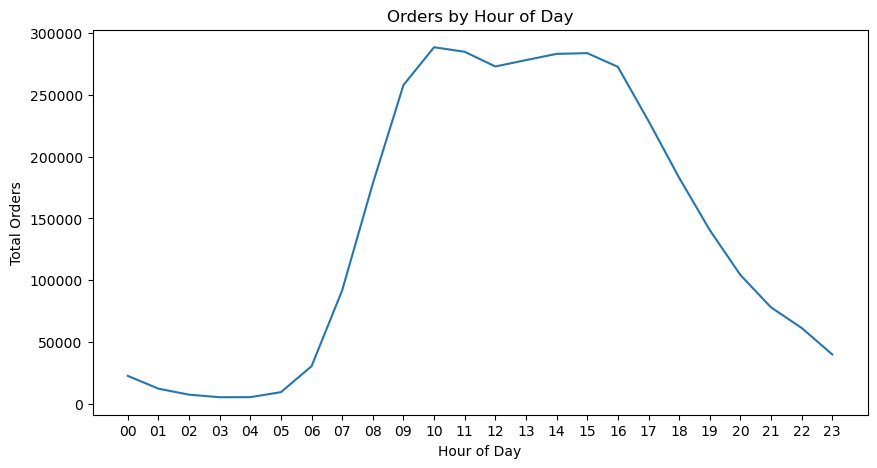

In [166]:
import pandas as pd
import matplotlib.pyplot as plt

# SQL Query
query = """
SELECT 
    order_hour_of_day,
    COUNT(order_id) AS Total_Orders
FROM orders
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day
"""

# Load query into dataframe
df = con.execute(query).fetchdf()

# Create visualization
plt.figure(figsize=(10,5))
plt.plot(df['order_hour_of_day'], df['Total_Orders'])

# Labels
plt.xlabel("Hour of Day")
plt.ylabel("Total Orders")
plt.title("Orders by Hour of Day")

# Show chart
plt.show()

## Observation — Orders by Hour of Day

Customer purchasing activity is lowest during late-night and early-morning hours, while orders increase significantly during daytime hours. The highest order volume occurs between morning and afternoon hours, indicating that customers prefer grocery shopping during active daily routines rather than late-night periods.

In [168]:
## Orders by Day Of Week

con.execute(""" SELECT order_dow, COUNT(order_id) AS Total_Orders
                FROM orders
                GROUP BY order_dow """).df()

,order_dow,Total_Orders
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


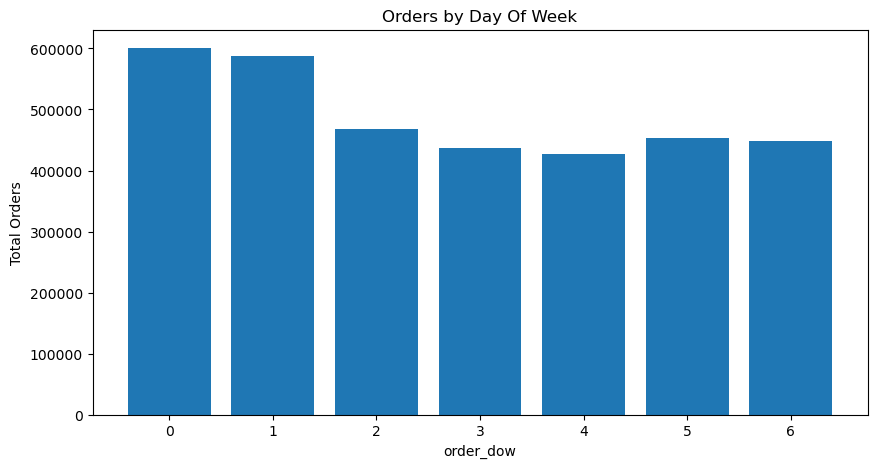

In [170]:
# SQL Query
query = """
            SELECT order_dow, COUNT(order_id) AS Total_Orders
            FROM orders
            GROUP BY order_dow """

# Load query into dataframe
df = con.execute(query).fetchdf()

# Create visualization
plt.figure(figsize=(10,5))
plt.bar(df['order_dow'], df['Total_Orders'])

# Labels
plt.xlabel("order_dow")
plt.ylabel("Total Orders")
plt.title("Orders by Day Of Week")

# Show chart
plt.show()

## Observation — Orders by Day of Week

Order activity is unevenly distributed across the week, with certain days receiving noticeably higher order volumes than others. This suggests that customer grocery purchasing behavior is influenced by weekly shopping habits, where customers tend to place more orders during preferred shopping days.

In [171]:
## Top Departments

con.execute("""
    SELECT d.department, COUNT(op.product_id) AS Total_Purchases
        FROM departments d
        LEFT JOIN products p
        ON p.department_id = d.department_id
            LEFT JOIN order_products op
            ON op.product_id = p.product_id
            GROUP BY d.department
            ORDER BY Total_Purchases DESC
""").df()

,department,Total_Purchases
0,produce,9479291
1,dairy eggs,5414016
2,snacks,2887550
3,beverages,2690129
4,frozen,2236432
5,pantry,1875577
6,bakery,1176787
7,canned goods,1068058
8,deli,1051249
9,dry goods pasta,866627


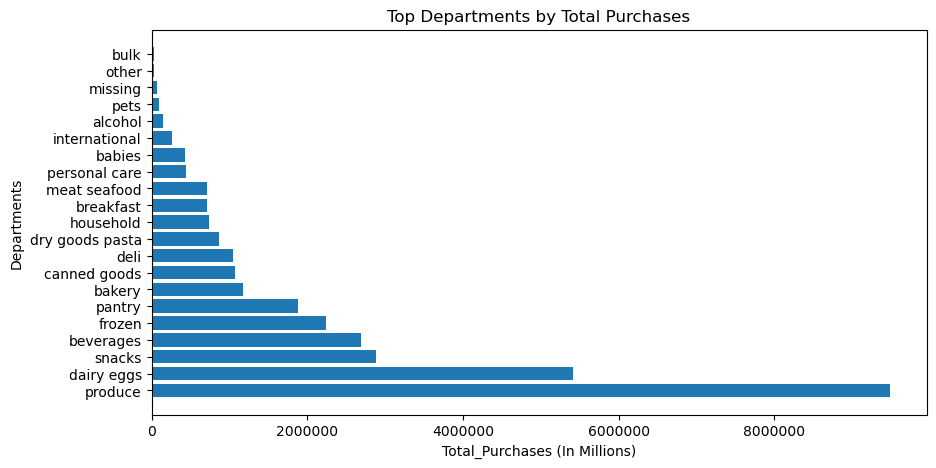

In [179]:
# SQL Query
query = """
            SELECT d.department, COUNT(op.product_id) AS Total_Purchases
        FROM departments d
        LEFT JOIN products p
        ON p.department_id = d.department_id
            LEFT JOIN order_products op
            ON op.product_id = p.product_id
            GROUP BY d.department
            ORDER BY Total_Purchases DESC """

# Load query into dataframe
df = con.execute(query).fetchdf()

# Create visualization
plt.figure(figsize=(10,5))
df['Total_Purchases'] == df['Total_Purchases'] / 1000000 
plt.barh(df['department'], df['Total_Purchases'])

# Labels
plt.xlabel("Total_Purchases (In Millions)")
plt.ylabel("Departments")
plt.title("Top Departments by Total Purchases")

plt.ticklabel_format(style='plain', axis='x')

# Show chart
plt.show()

## Observation — Top Departments

The Produce department generated the highest number of purchases, followed by Dairy Eggs and Snacks. This indicates that fresh and frequently consumed grocery items dominate customer purchasing behavior, while niche departments such as Bulk and Other contribute relatively lower sales volumes.

In [180]:
## Reorder Rate by Loyalty Group

con.execute("""SELECT AVG(op.reordered) AS Average_Reordered, o.Loyalty_Group

    FROM (
            SELECT o.order_id, lg.Loyalty_Group
            
                    FROM (

                        SELECT user_id, COUNT(order_id) AS Total_Orders, 
                            CASE 
                                WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                ELSE 'Loyal Customers' END AS Loyalty_Group

                        FROM orders
                        GROUP BY user_id
             
                        ) lg

            LEFT JOIN orders o
            ON o.user_id = lg.user_id
            GROUP BY o.order_id, lg.Loyalty_Group

                ) o

        LEFT JOIN order_products op
        ON o.order_id = op.order_id

        GROUP BY o.Loyalty_Group """).df()
        


,Average_Reordered,Loyalty_Group
0,0.507756,Regular Customers
1,0.688497,Loyal Customers
2,0.334741,Casual Customers


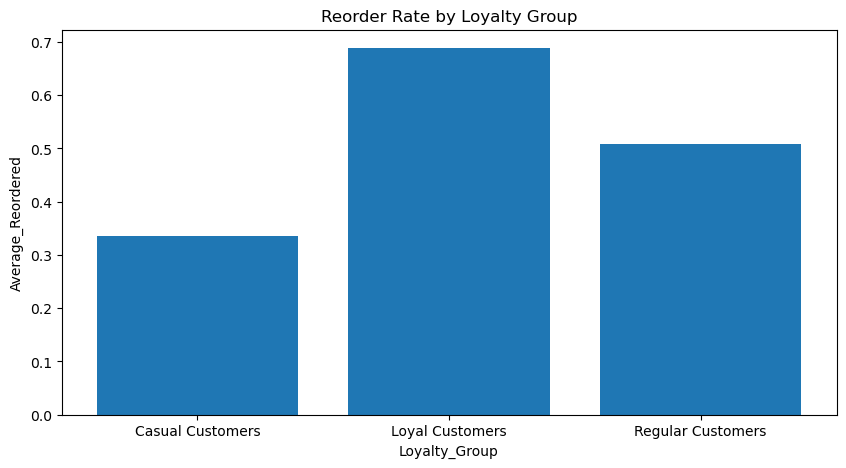

In [183]:
# SQL Query
query = """
            SELECT AVG(op.reordered) AS Average_Reordered, o.Loyalty_Group

    FROM (
            SELECT o.order_id, lg.Loyalty_Group
            
                    FROM (

                        SELECT user_id, COUNT(order_id) AS Total_Orders, 
                            CASE 
                                WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                ELSE 'Loyal Customers' END AS Loyalty_Group

                        FROM orders
                        GROUP BY user_id
             
                        ) lg

            LEFT JOIN orders o
            ON o.user_id = lg.user_id
            GROUP BY o.order_id, lg.Loyalty_Group

                ) o

        LEFT JOIN order_products op
        ON o.order_id = op.order_id

        GROUP BY o.Loyalty_Group """

# Load query into dataframe
df = con.execute(query).fetchdf()

# Create visualization
plt.figure(figsize=(10,5))
plt.bar(df['Loyalty_Group'], df['Average_Reordered'])

# Labels
plt.xlabel("Loyalty_Group")
plt.ylabel("Average_Reordered")
plt.title("Reorder Rate by Loyalty Group")


# Show chart
plt.show()

## Observation — Reorder Rate by Loyalty Group

Loyal customers show the highest reorder rate compared to Regular and Casual customers. This suggests that highly engaged customers are more likely to repeatedly purchase the same products, reflecting stronger brand familiarity and consistent shopping behavior.

In [193]:
## Basket Size by Loyalty Group

con.execute(""" SELECT AVG(Basket_Size) AS Avg_Basket_Size, Loyalty_Group

FROM (
            SELECT COUNT(op.product_id) AS Basket_Size, o.Loyalty_Group

                FROM (
                     SELECT o.order_id, lg.Loyalty_Group
            
                        FROM (

                            SELECT user_id, COUNT(order_id) AS Total_Orders, 
                                CASE 
                                    WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                    WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                    ELSE 'Loyal Customers' END AS Loyalty_Group

                                FROM orders
                                GROUP BY user_id
             
                        ) lg

            LEFT JOIN orders o
            ON o.user_id = lg.user_id
            GROUP BY o.order_id, lg.Loyalty_Group

                ) o

        LEFT JOIN order_products op
        ON o.order_id = op.order_id

        GROUP BY o.order_id, o.Loyalty_Group

        )
        
GROUP BY Loyalty_Group     

        """).df()
        

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Avg_Basket_Size,Loyalty_Group
0,8.252986,Casual Customers
1,9.372659,Regular Customers
2,9.926409,Loyal Customers


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

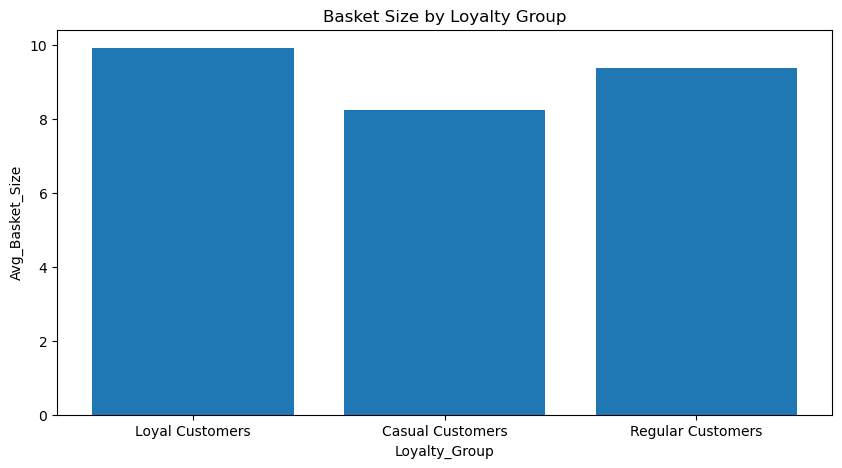

In [195]:
# SQL Query
query = """
            SELECT AVG(Basket_Size) AS Avg_Basket_Size, Loyalty_Group

FROM (
            SELECT COUNT(op.product_id) AS Basket_Size, o.Loyalty_Group

                FROM (
                     SELECT o.order_id, lg.Loyalty_Group
            
                        FROM (

                            SELECT user_id, COUNT(order_id) AS Total_Orders, 
                                CASE 
                                    WHEN COUNT(order_id) <= 10 THEN 'Casual Customers'
                                    WHEN COUNT(order_id) >= 11 AND COUNT(order_id) <= 20 THEN 'Regular Customers'
                                    ELSE 'Loyal Customers' END AS Loyalty_Group

                                FROM orders
                                GROUP BY user_id
             
                        ) lg

            LEFT JOIN orders o
            ON o.user_id = lg.user_id
            GROUP BY o.order_id, lg.Loyalty_Group

                ) o

        LEFT JOIN order_products op
        ON o.order_id = op.order_id

        GROUP BY o.order_id, o.Loyalty_Group

        )
        
GROUP BY Loyalty_Group     
 """

# Load query into dataframe
df = con.execute(query).fetchdf()

# Create visualization
plt.figure(figsize=(10,5))
plt.bar(df['Loyalty_Group'], df['Avg_Basket_Size'])

# Labels
plt.xlabel("Loyalty_Group")
plt.ylabel("Avg_Basket_Size")
plt.title("Basket Size by Loyalty Group")

# Show chart
plt.show()

## Observation — Basket Size by Loyalty Group

Loyal customers tend to have the largest average basket sizes, while Casual customers purchase fewer items per order. This indicates that customer loyalty is strongly associated with higher purchasing volume and deeper shopping engagement per transaction.

# Step 7.7 — Final Insights Summary

## Objective

Summarize the overall findings of the Instacart customer purchasing analysis project by highlighting major customer behavior trends, loyalty patterns, shopping activity insights, and department performance observations.

---

## Observation

- This analysis provided a deeper understanding of how customers interact with the Instacart platform and how their shopping behavior changes across products, departments, and time periods.

- The results showed that customers mainly purchase everyday grocery essentials such as produce, dairy products, and snacks, making these categories the most important drivers of overall purchasing activity. Customers also displayed strong reorder behavior for commonly used items, which highlights the importance of repeat purchasing patterns in grocery retail.

- Loyal customers consistently placed larger orders and showed higher reorder activity compared to casual shoppers, suggesting that customer retention and loyalty programs could play a major role in long-term business growth.

- Time-based analysis revealed that most shopping activity occurs during daytime and evening hours, while late-night ordering remains relatively low. Weekly shopping trends also showed that customers tend to place more orders during specific days of the week, reflecting routine grocery shopping habits.

- Overall, the project successfully transformed raw transactional data into meaningful business insights related to customer behavior, purchasing patterns, operational planning, and product performance. The analysis demonstrates how SQL and data analysis techniques can be used to support data-driven decision-making in e-commerce and retail environments.